# CLEAR-IT Figure E2

Here, we generate the plots shown in Figure E2.

First, let's load the required modules.

In [ ]:
from pathlib import Path
import pandas as pd
from clearit.config import OUTPUTS_DIR
from clearit.plotting.boxplot import boxplot_performance
from clearit.metrics.gather_pr_auc import gather_pr_auc
from clearit.plotting.utils import build_single_patient_entries
from clearit.metrics.gather_scatter_data import (
    prepare_scatter_dataframe_single_patient_networks,
)

## Figure E2a
a) shows the PR-AUC scores (both per class and the class-agnostic "total" scores) for linear evaluation of the encoders trained on images from a single patient in the TNBC1-MxIF8 dataset(using the corresponding TME-A_ML6 labels).

Let's first define the `entries` dictionary using a helper function that points to all relevant test results. We also load the TNBC1-MxIF8 image statistics in order to sort the patients by image quality using the proposed image quality metric (based on standard deviation of top 0.1% pixels).

In [22]:
# Build entries
entries = build_single_patient_entries(
    patient_start=1,
    patient_end=47,
    test_start_id=412,
    dataset_label="TNBC1-MxIF8",
)

# Load image statistics
image_stats_csv = Path(
    OUTPUTS_DIR, "ranking", "TNBC1-MxIF8", "image_statistics_extended.csv"
)

Next, we gather the results from the defined entries and compute the PR-AUC scores across 10 splits of the test set in the dataframe `df_a_prauc`.

In [ ]:
df_a_prauc = gather_pr_auc(
    entries,
    chunks=10, # compute the scores across 10 splits of the data
    total=False # compute the class-agnostic PR-AUC
    )
# Rename contents of "Group" column to indicate class labels
df_a_prauc.Group = df_a_prauc.Group.replace("0","CK+").replace("1","CD3+").replace("2","CD8+").replace("3","CD20+").replace("4","CD56+").replace("5","CD68+")

Next, we compute `df_a_scatter` that contains information about the image quality necessary for sorting (see also Figure E3).

In [ ]:
# Prepare dataframe with ranking metrics
df_a_scatter = prepare_scatter_dataframe_single_patient_networks(
    entries,
    image_stats_csv,
)

In the plot, we want to show not only the patient IDs on the x axis, but also the corresponding image quality ranking associated with that patient. In order to do that, we process the generated dataframes.

In [ ]:
# 1. Build a mapping from patient_id -> "Pxx (y.yy)"
tmp = df_a_scatter[['patient_id', 'Normalized_Score_std']].drop_duplicates('patient_id')

tmp['new_label'] = tmp.apply(
    lambda r: f"{r['patient_id']} ({r['Normalized_Score_std']:.2f})",
    axis=1
)

id_to_label = dict(zip(tmp['patient_id'], tmp['new_label']))

# 2. Update df_a_scatter.patient_id in place
df_a_scatter['patient_id'] = df_a_scatter['patient_id'].map(id_to_label)

# 3. Update df_a_prauc.Configuration in place
#    (using fillna to keep any values that don't appear in the mapping)
df_a_prauc['Configuration'] = df_a_prauc['Configuration'].map(id_to_label).fillna(df_a_prauc['Configuration'])


We also want to order the patients from the highest mean of median PR-AUC to the lowest. The `boxplot_performance` function computes the mean of medians, so we can run it silently once to generate `df_a_order` that can be used to define the ordering for the actual plot.

In [27]:
_, df_a_order, _ = boxplot_performance(
    df_a_prauc,
    show=False
)

config_a_order = []
p_list = df_a_order.sort_values("mean_of_medians").index.tolist()
for e in p_list:
    cfg = e
    if cfg not in config_a_order:
        config_a_order.append(cfg)
config_a_order.reverse()

Finally, we run the `boxplot_performance` function and have it produce the desired plot. We also display the summary table `df_a_out` and generate `tables_a` which contains the raw plotting data.

,CK+,CD3+,CD8+,CD20+,CD56+,CD68+,total,mean_of_medians
Configuration,,,,,,,,
P33 (0.67),0.832987,0.734143,0.836217,0.899932,0.623019,0.782192,0.806962,0.784748
P36 (0.77),0.854114,0.689744,0.787767,0.907659,0.538068,0.764711,0.780795,0.757010
P20 (0.74),0.840449,0.750499,0.793644,0.872862,0.474961,0.727466,0.789204,0.743314
P38 (0.69),0.822177,0.752978,0.769364,0.880913,0.462666,0.696525,0.761083,0.730771
P21 (0.77),0.875169,0.720441,0.817650,0.915546,0.328251,0.720116,0.801157,0.729529
P07 (0.72),0.781147,0.693232,0.810673,0.888353,0.510905,0.672157,0.731826,0.726078
P44 (0.64),0.820619,0.738213,0.794648,0.874972,0.392937,0.721142,0.779142,0.723755
P47 (0.72),0.847856,0.710188,0.780089,0.880931,0.329522,0.753355,0.776414,0.716990
P09 (0.75),0.858436,0.687864,0.797261,0.884813,0.328602,0.679354,0.753058,0.706055


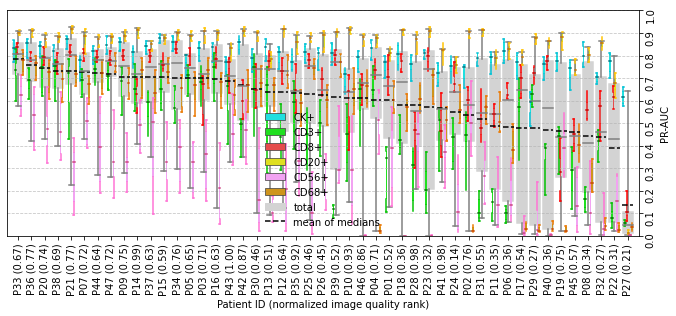

In [60]:
# generate the plot
ax, df_a_out, tables_a = boxplot_performance(
    df_a_prauc,
    value_col="Value",
    show_total=True,
    show_mean_of_medians=True,
    order=config_a_order,
    figsize=(9.5,4.5),
    xtick_rotation=90,
    xlabel="Patient ID (normalized image quality rank)",
    ytick_rotation=90,
    ylim=[0.0,1.00],
    yticks=[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],    
    ylabel="PR-AUC",
    yaxis_right=True,
    legend_loc="lower center",
    legend_ncol=1,
)
# display the resulting dataframe
display(df_a_out)

# save plot
fig = ax.get_figure()
fig.savefig("E2a.svg", format="svg")

`tables_a` can be exported into an Excel file `E2a.xlsx` which contains the raw data required to reproduce the plot as shown, without having to process any of the underlying data.

In [ ]:
with pd.ExcelWriter("E2a.xlsx") as writer:
    for sheet_name, tbl in tables_a.items():
        tbl.to_excel(writer, sheet_name=str(sheet_name))

## Figure E2b
a) shows the PR-AUC scores (both per class and the class-agnostic "total" scores) for linear evaluation of the encoders trained on images from a single patient in the TNBC2-MIBI8 dataset(using the corresponding TME-A_ML6 labels).

Let's first define the `entries` dictionary using a helper function that points to all relevant test results. We also load the TNBC2-MIBI8 image statistics in order to sort the patients by image quality using the proposed image quality metric (based on standard deviation of top 0.1% pixels).

In [30]:
# Build entries
entries = build_single_patient_entries(
    patient_start=1,
    patient_end=30,
    test_start_id=626,
    dataset_label="TNBC2-MIBI8",
)

# Load image statistics
image_stats_csv = Path(
    OUTPUTS_DIR, "ranking", "TNBC2-MIBI8", "image_statistics_extended.csv"
)

Next, we gather the results from the defined entries and compute the PR-AUC scores across 10 splits of the test set in the dataframe `df_b_prauc`.

In [31]:
df_b_prauc = gather_pr_auc(
    entries,
    chunks=10, # compute the scores across 10 splits of the data
    total=False # compute the class-agnostic PR-AUC
    )
# Rename contents of "Group" column to indicate class labels
df_b_prauc.Group = df_b_prauc.Group.replace("0","CK+").replace("1","CD3+").replace("2","CD8+").replace("3","CD20+").replace("4","CD56+").replace("5","CD68+")

Next, we compute `df_b_scatter` that contains information about the image quality necessary for sorting (see also Figure E3).

In [32]:
# Prepare dataframe with ranking metrics
df_b_scatter = prepare_scatter_dataframe_single_patient_networks(
    entries,
    image_stats_csv,
)

In the plot, we want to show not only the patient IDs on the x axis, but also the corresponding image quality ranking associated with that patient. In order to do that, we process the generated dataframes.

In [33]:
# 1. Build a mapping from patient_id -> "Pxx (y.yy)"
tmp = df_b_scatter[['patient_id', 'Normalized_Score_std']].drop_duplicates('patient_id')

tmp['new_label'] = tmp.apply(
    lambda r: f"{r['patient_id']} ({r['Normalized_Score_std']:.2f})",
    axis=1
)

id_to_label = dict(zip(tmp['patient_id'], tmp['new_label']))

# 2. Update df_b_scatter.patient_id in place
df_b_scatter['patient_id'] = df_b_scatter['patient_id'].map(id_to_label)

# 3. Update df_b_prauc.Configuration in place
#    (using fillna to keep any values that don't appear in the mapping)
df_b_prauc['Configuration'] = df_b_prauc['Configuration'].map(id_to_label).fillna(df_b_prauc['Configuration'])


We also want to order the patients from the highest mean of median PR-AUC to the lowest. The `boxplot_performance` function computes the mean of medians, so we can run it silently once to generate `df_b_order` that can be used to define the ordering for the actual plot.

In [34]:
_, df_b_order, _ = boxplot_performance(
    df_b_prauc,
    show=False
)

config_b_order = []
p_list = df_b_order.sort_values("mean_of_medians").index.tolist()
for e in p_list:
    cfg = e
    if cfg not in config_b_order:
        config_b_order.append(cfg)
config_b_order.reverse()

Finally, we run the `boxplot_performance` function and have it produce the desired plot. We also display the summary table `df_b_out` and generate `tables_b` which contains the raw plotting data.

,CK+,CD3+,CD8+,CD20+,CD56+,CD68+,total,mean_of_medians
Configuration,,,,,,,,
P10 (0.72),0.968228,0.935015,0.929041,0.831424,0.893304,0.934410,0.929041,0.915237
P03 (0.70),0.961240,0.943196,0.917618,0.911963,0.818503,0.929457,0.929183,0.913663
P17 (0.97),0.953081,0.945339,0.933191,0.876517,0.846066,0.899597,0.921516,0.908965
P16 (1.00),0.955463,0.853464,0.872407,0.920797,0.900858,0.928933,0.921638,0.905320
P13 (0.96),0.917937,0.896785,0.921971,0.908438,0.874883,0.901364,0.907978,0.903563
P12 (0.90),0.954917,0.928907,0.932592,0.865306,0.845626,0.869617,0.902733,0.899494
P09 (0.81),0.960542,0.924059,0.926174,0.846511,0.809097,0.919848,0.921403,0.897705
P30 (0.74),0.953790,0.876729,0.903340,0.733637,0.875671,0.911596,0.906051,0.875794
P29 (0.79),0.966273,0.923918,0.863150,0.774889,0.806404,0.884291,0.880682,0.869821


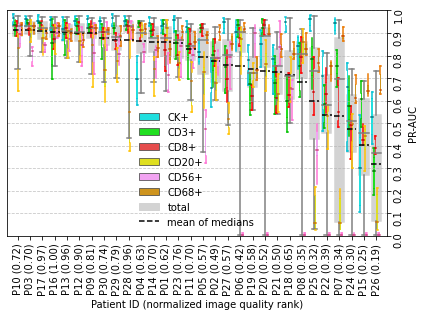

In [59]:
# generate the plot
ax, df_b_out, tables_b = boxplot_performance(
    df_b_prauc,
    value_col="Value",
    show_total=True,
    show_mean_of_medians=True,
    order=config_b_order,
    figsize=(6,4.5),
    xtick_rotation=90,
    xlabel="Patient ID (normalized image quality rank)",
    ytick_rotation=90,
    ylim=[0.0,1.00],
    yticks=[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
    ylabel="PR-AUC",
    yaxis_right=True,
    legend_loc="lower center",
    legend_ncol=1,
)
# display the resulting dataframe
display(df_b_out)

# save plot
fig = ax.get_figure()
fig.savefig("E2b.svg", format="svg")

`tables_b` can be exported into an Excel file `E2b.xlsx` which contains the raw data required to reproduce the plot as shown, without having to process any of the underlying data.

In [ ]:
with pd.ExcelWriter("E2b.xlsx") as writer:
    for sheet_name, tbl in tables_b.items():
        tbl.to_excel(writer, sheet_name=str(sheet_name))